# Phase 2 — Step 1: ETL Pipeline + Isolation Forest

**Goal:** Read the raw server logs from DuckDB, build 12 engineered features with Polars, then run an Isolation Forest to flag anomalous queries as CRITICAL / WARNING / OK.

**Stack:** DuckDB · Polars · Scikit-Learn (Isolation Forest)

In [1]:
import polars as pl
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

FIGURES  = "../data/figures"
DB_PATH  = "../data/apex.duckdb"
CSV_PATH = "../data/processed_logs.csv"
os.makedirs(FIGURES, exist_ok=True)
sns.set_theme(style="darkgrid")
print("Setup complete.")


Setup complete.


In [2]:
# ── EXTRACT ── read-only connection (safe to run alongside other notebooks) ───
conn_r = duckdb.connect(DB_PATH, read_only=True)

tables = [t[0] for t in conn_r.execute("SHOW TABLES").fetchall()]
if "raw_logs" not in tables:
    conn_r.close()
    raise RuntimeError("raw_logs table missing. Run Phase 1 / Notebook 1 first.")

df = conn_r.execute("SELECT * FROM raw_logs").pl()
conn_r.close()   # release immediately — done reading

df = df.with_columns(
    pl.col("timestamp").str.to_datetime("%Y-%m-%d %H:%M:%S"),
    pl.col("execution_time_ms").cast(pl.Float64),
    pl.col("server_cpu_load").cast(pl.Float64),
)
print(f"Extracted {len(df):,} rows from raw_logs")
print(df.head(3))

Extracted 15,000 rows from raw_logs
shape: (3, 6)
┌─────────────────────┬────────────┬───────────────┬───────────────────┬─────────────────┬─────────┐
│ timestamp           ┆ query_type ┆ target_table  ┆ execution_time_ms ┆ server_cpu_load ┆ status  │
│ ---                 ┆ ---        ┆ ---           ┆ ---               ┆ ---             ┆ ---     │
│ datetime[μs]        ┆ str        ┆ str           ┆ f64               ┆ f64             ┆ str     │
╞═════════════════════╪════════════╪═══════════════╪═══════════════════╪═════════════════╪═════════╡
│ 2024-01-21 03:01:47 ┆ INSERT     ┆ products      ┆ 104.0             ┆ 65.33           ┆ SUCCESS │
│ 2024-01-22 23:57:34 ┆ DELETE     ┆ orders        ┆ 638.0             ┆ 98.0            ┆ SUCCESS │
│ 2024-01-20 00:35:12 ┆ DELETE     ┆ order_reviews ┆ 143.0             ┆ 68.24           ┆ SUCCESS │
└─────────────────────┴────────────┴───────────────┴───────────────────┴─────────────────┴─────────┘


In [3]:
# ── TRANSFORM — engineer 12 features with Polars ─────────────────────────────
QUERY_MAP = {"SELECT": 0, "INSERT": 1, "UPDATE": 2, "DELETE": 3}
TABLE_MAP  = {"orders": 0, "customers": 1, "products": 2, "order_items": 3, "order_reviews": 4}

df = df.with_columns([
    pl.col("timestamp").dt.hour().alias("hour_of_day"),
    pl.col("timestamp").dt.weekday().alias("day_of_week"),
    # Feature flags
    pl.when(pl.col("timestamp").dt.hour().is_between(18, 22))
      .then(1).otherwise(0).cast(pl.Int32).alias("is_peak_hour"),
    pl.when(pl.col("execution_time_ms") > 2000)
      .then(1).otherwise(0).cast(pl.Int32).alias("is_slow_query"),
    pl.when(pl.col("server_cpu_load") > 75)
      .then(1).otherwise(0).cast(pl.Int32).alias("is_high_cpu"),
    pl.when(pl.col("target_table") == "orders")
      .then(1).otherwise(0).cast(pl.Int32).alias("is_orders_table"),
    # Encoded categoricals
    pl.col("query_type").replace(QUERY_MAP).cast(pl.Int32).alias("qt_code"),
    pl.col("target_table").replace(TABLE_MAP).cast(pl.Int32).alias("tbl_code"),
    # Log-transform execution time (reduces outlier influence on the model)
    pl.col("execution_time_ms").log(base=10).alias("log_exec_time"),
])

print(f"Features engineered. DataFrame shape: {df.shape}")
print("New columns:", ["hour_of_day","day_of_week","is_peak_hour","is_slow_query",
                       "is_high_cpu","is_orders_table","qt_code","tbl_code","log_exec_time"])


Features engineered. DataFrame shape: (15000, 15)
New columns: ['hour_of_day', 'day_of_week', 'is_peak_hour', 'is_slow_query', 'is_high_cpu', 'is_orders_table', 'qt_code', 'tbl_code', 'log_exec_time']


In [4]:
# ── Isolation Forest — unsupervised anomaly detection ─────────────────────────
ISO_FEATURES = ["log_exec_time", "server_cpu_load", "hour_of_day",
                "qt_code", "tbl_code", "is_peak_hour"]

X = df.select(ISO_FEATURES).to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    contamination = 0.05,   # expect ~5% anomalies
    n_estimators  = 200,
    random_state  = 42,
)
iso.fit(X_scaled)

scores = iso.decision_function(X_scaled)   # negative = more anomalous
flags  = iso.predict(X_scaled)             # -1 = anomaly, 1 = normal

df = df.with_columns([
    pl.Series("anomaly_score", scores.tolist()),
    pl.Series("is_anomaly",    [1 if f == -1 else 0 for f in flags]).cast(pl.Int32),
])

print(f"Anomalies detected : {df['is_anomaly'].sum():,}  ({df['is_anomaly'].mean():.2%})")


Anomalies detected : 750  (5.00%)


In [5]:
# ── Risk level classification ─────────────────────────────────────────────────
df = df.with_columns(
    pl.when(
        (pl.col("is_anomaly") == 1) &
        (pl.col("is_high_cpu") == 1) &
        (pl.col("is_slow_query") == 1)
    ).then(pl.lit("CRITICAL"))
    .when(
        (pl.col("is_anomaly") == 1) |
        (pl.col("is_slow_query") == 1) |
        (pl.col("is_high_cpu") == 1)
    ).then(pl.lit("WARNING"))
    .otherwise(pl.lit("OK"))
    .alias("risk_level")
)

risk_counts = df.group_by("risk_level").agg(pl.len().alias("n")).sort("n", descending=True)
print(risk_counts)


shape: (3, 2)
┌────────────┬──────┐
│ risk_level ┆ n    │
│ ---        ┆ ---  │
│ str        ┆ u32  │
╞════════════╪══════╡
│ WARNING    ┆ 7884 │
│ OK         ┆ 6813 │
│ CRITICAL   ┆ 303  │
└────────────┴──────┘


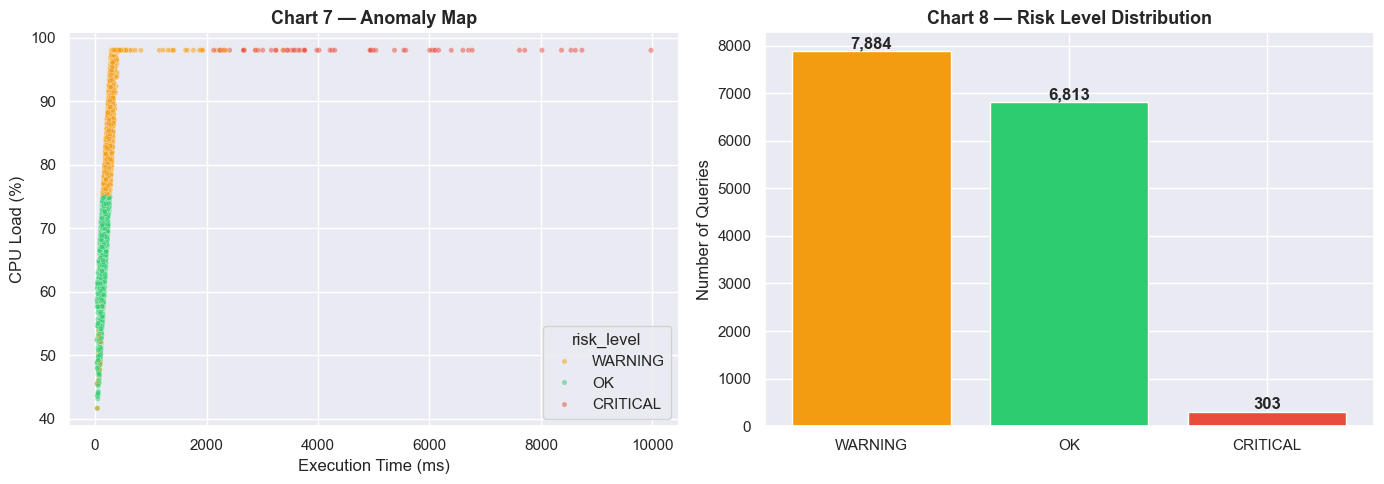

Charts 7-8 saved.


In [6]:
# ── Chart 7: Anomaly scatter — execution time vs CPU ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {"CRITICAL": "#e74c3c", "WARNING": "#f39c12", "OK": "#2ecc71"}
df_pd   = df.to_pandas()

# Scatter
sns.scatterplot(data=df_pd.sample(3000, random_state=42),
                x="execution_time_ms", y="server_cpu_load",
                hue="risk_level", palette=palette, alpha=0.5, s=15, ax=axes[0])
axes[0].set_title("Chart 7 — Anomaly Map", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Execution Time (ms)")
axes[0].set_ylabel("CPU Load (%)")

# Risk level bar
counts = df_pd["risk_level"].value_counts()
colors = [palette[r] for r in counts.index]
axes[1].bar(counts.index, counts.values, color=colors, edgecolor="white")
for i, (lvl, cnt) in enumerate(zip(counts.index, counts.values)):
    axes[1].text(i, cnt + 50, f"{cnt:,}", ha="center", fontweight="bold")
axes[1].set_title("Chart 8 — Risk Level Distribution", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Number of Queries")

plt.tight_layout()
plt.savefig(f"{FIGURES}/chart7_8_anomaly_detection.png", dpi=150)
plt.show()
print("Charts 7-8 saved.")


In [7]:
# ── LOAD ── open write connection only here, write, then close immediately ────
with duckdb.connect(DB_PATH) as conn_w:
    conn_w.register("clean_df", df)
    conn_w.execute("CREATE OR REPLACE TABLE clean_logs AS SELECT * FROM clean_df")

df.write_csv(CSV_PATH)
print(f"DuckDB  ->  {DB_PATH}  (table: clean_logs,  {len(df):,} rows)")
print(f"CSV     ->  {CSV_PATH}  ({len(df.columns)} columns)")
print()

rc = df.group_by("risk_level").agg(pl.len().alias("n")).sort("n", descending=True)
for row in rc.iter_rows(named=True):
    share = row["n"] / len(df)
    print(f"  {row['risk_level']:<10} {row['n']:>6,}  ({share:.1%})")


DuckDB  ->  ../data/apex.duckdb  (table: clean_logs,  15,000 rows)
CSV     ->  ../data/processed_logs.csv  (18 columns)

  WARNING     7,884  (52.6%)
  OK          6,813  (45.4%)
  CRITICAL      303  (2.0%)
